# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Pranaja Adyatma Budiman | 5054251009|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB, GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay
)



In [2]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

df = pd.read_csv('mushrooms.csv')

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.

df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

(8124, 23)

In [4]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

jumlah_unik = df.nunique()

print("Jumlah Nilai Unik per Fitur:")
print(jumlah_unik)

Jumlah Nilai Unik per Fitur:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


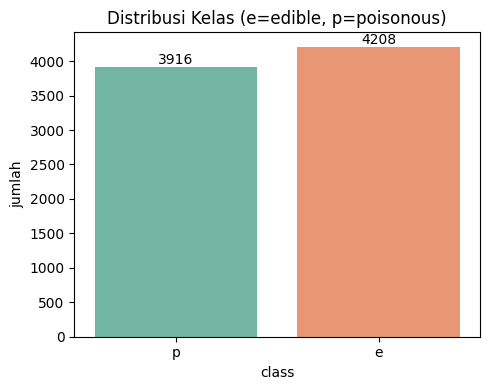

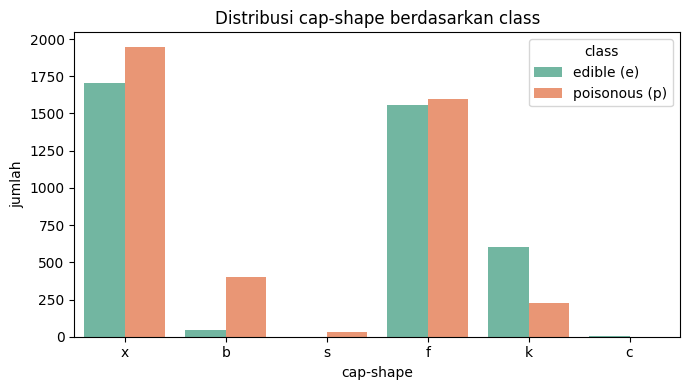

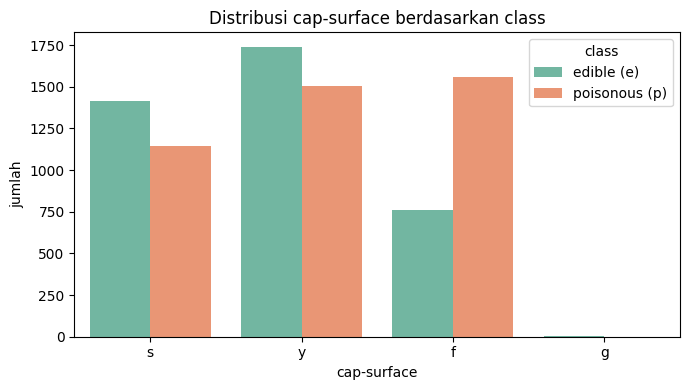

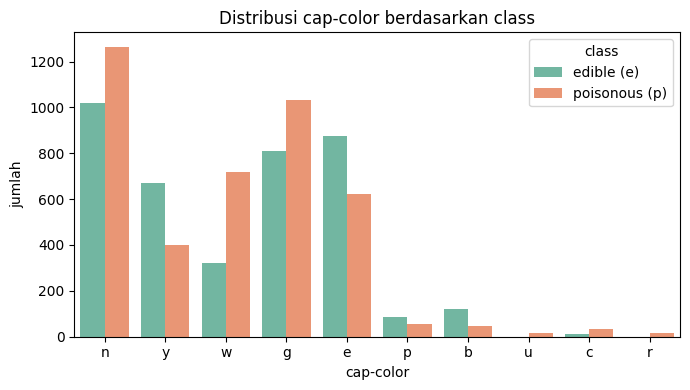

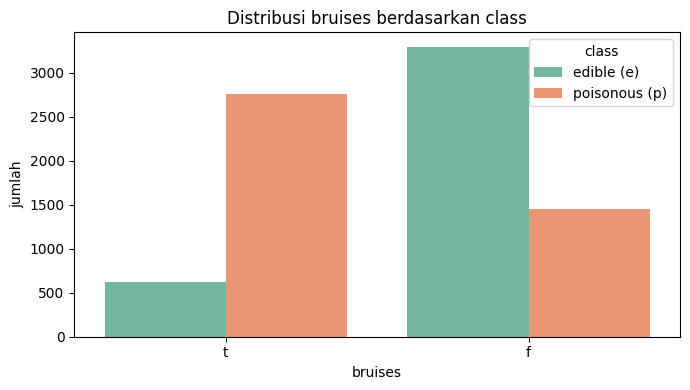

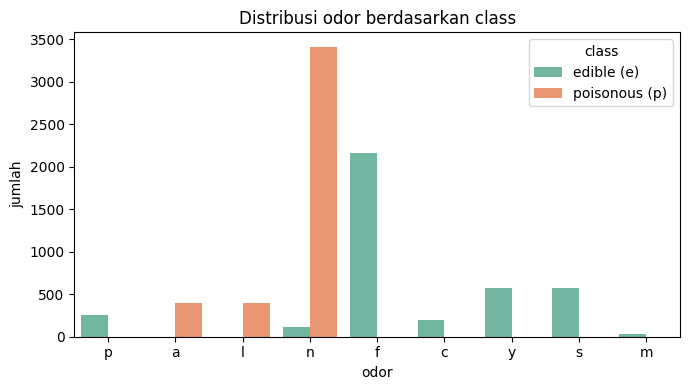

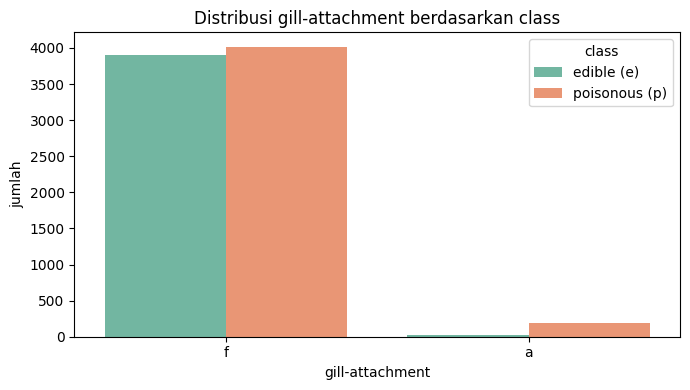

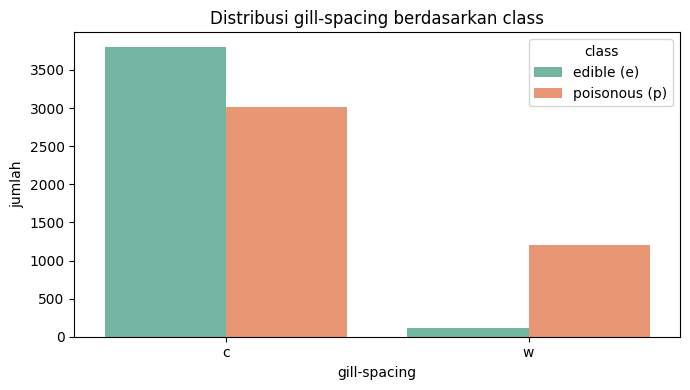

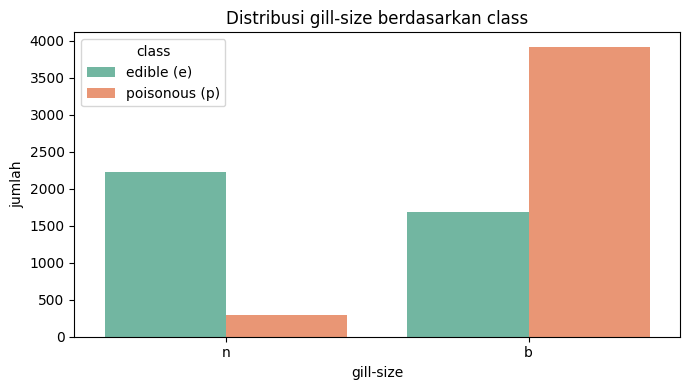

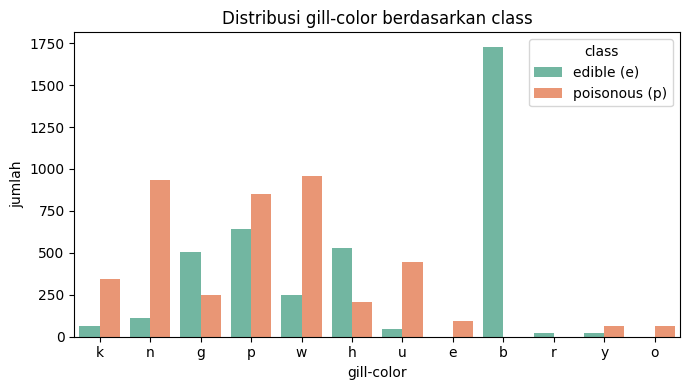

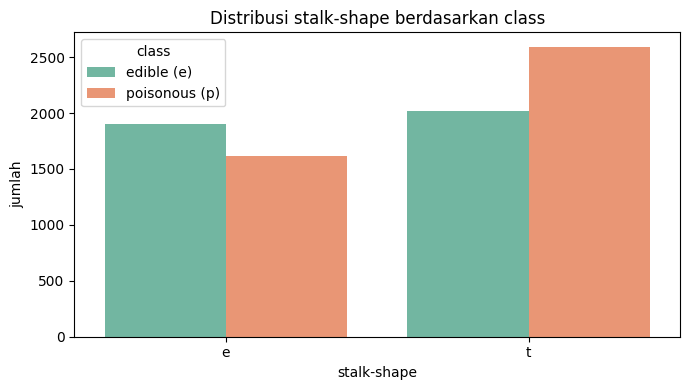

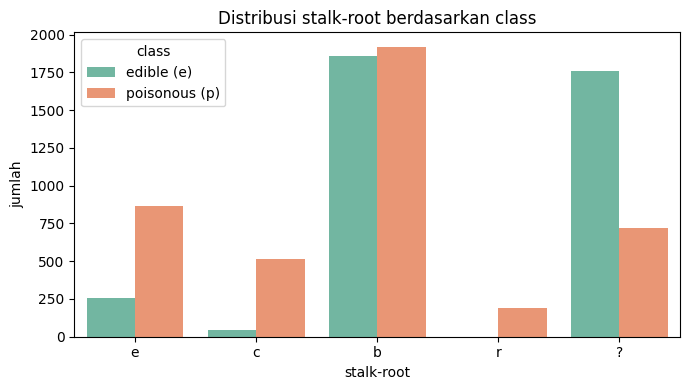

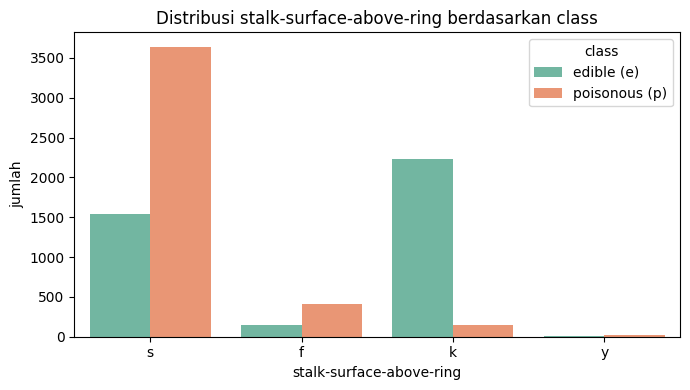

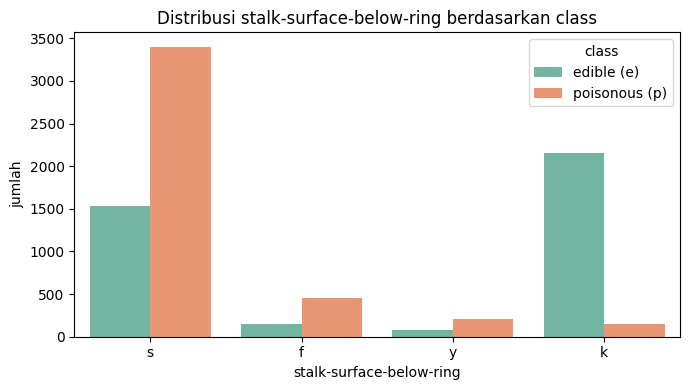

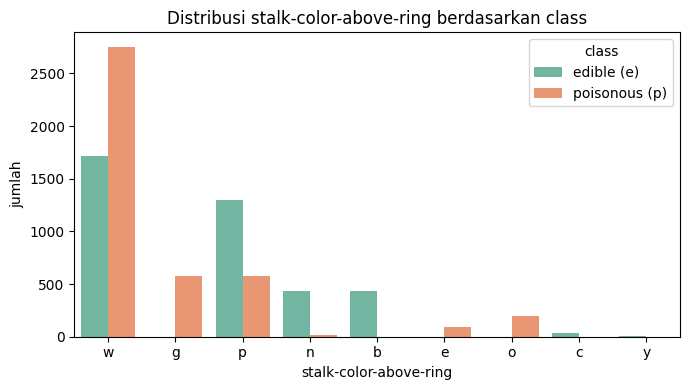

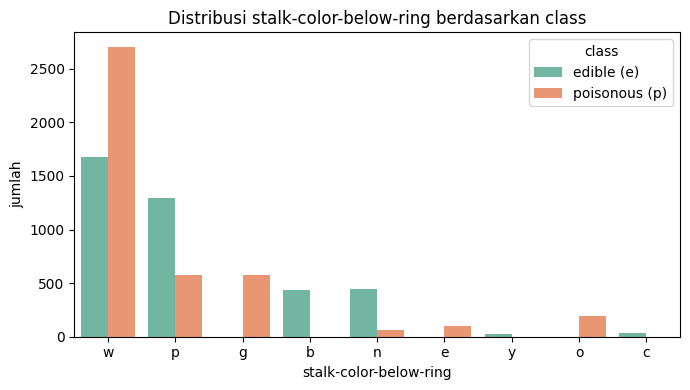

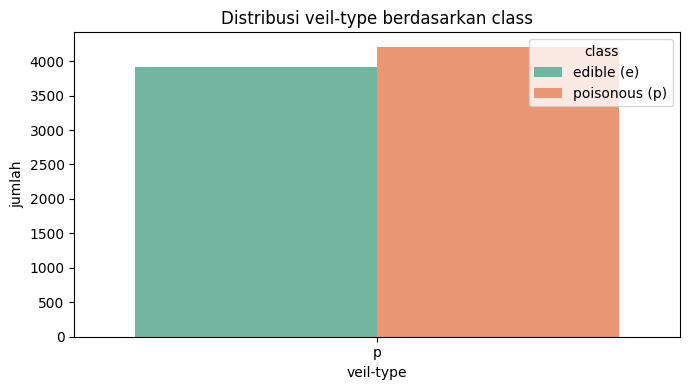

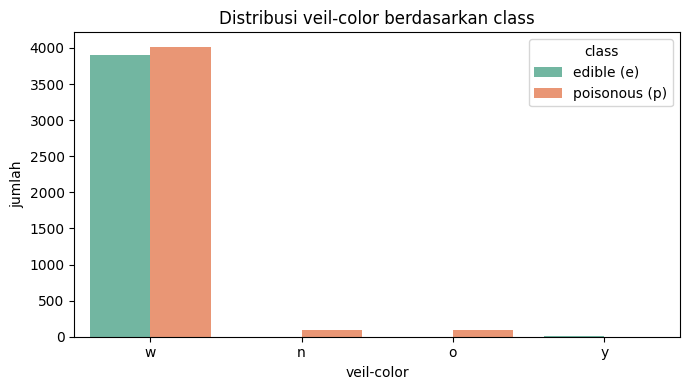

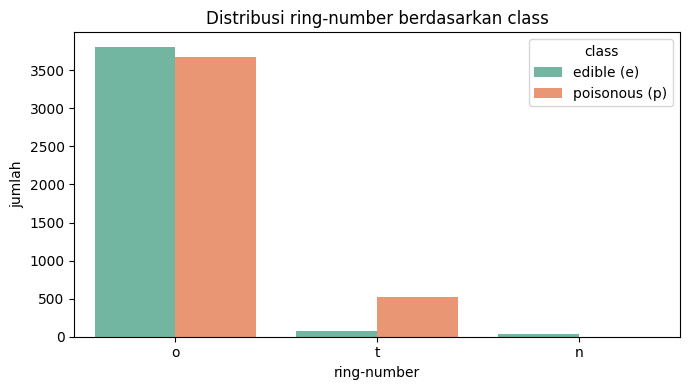

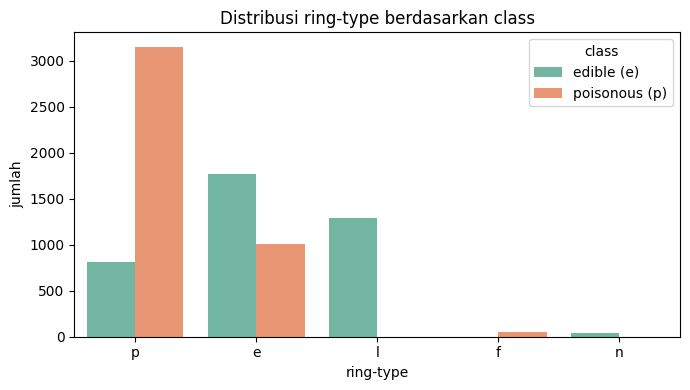

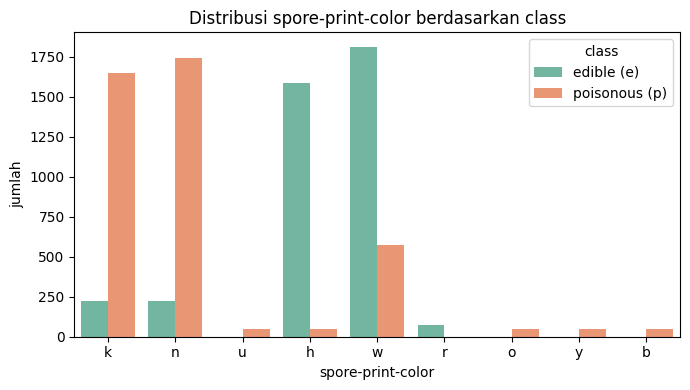

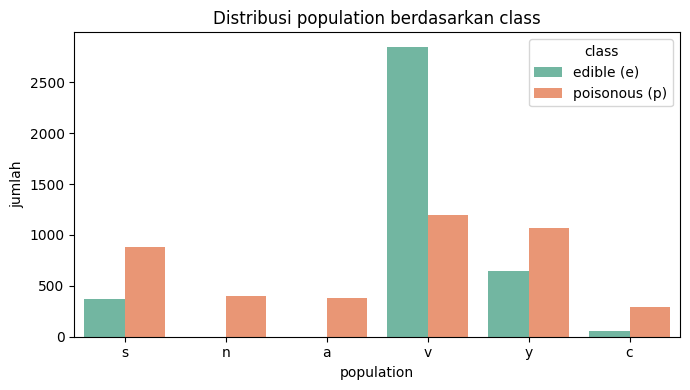

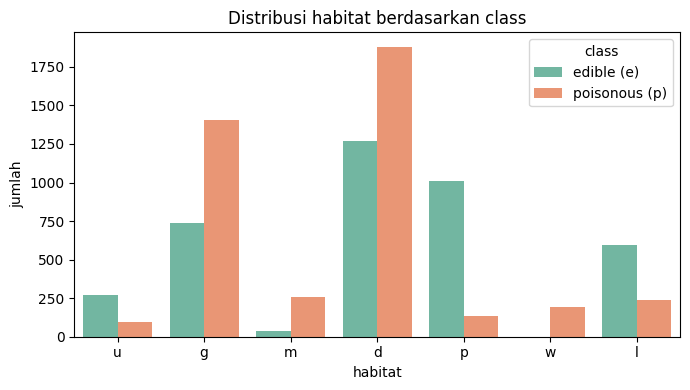

In [5]:
cat_cols = df.columns.drop('class')

# 1. Lihat distribusi target dulu
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='class', hue='class', palette='Set2', legend=False)
plt.title('Distribusi Kelas (e=edible, p=poisonous)')
plt.xlabel('class')
plt.ylabel('jumlah')
for container in plt.gca().containers:
    plt.gca().bar_label(container)
plt.tight_layout()
plt.show()

# 2. Persebaran tiap fitur dibedakan berdasarkan kelas
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue='class', palette='Set2')
    plt.title(f'Distribusi {col} berdasarkan class')
    plt.xlabel(col)
    plt.ylabel('jumlah')
    plt.xticks(rotation=0)
    plt.legend(title='class', labels=['edible (e)', 'poisonous (p)'])
    plt.tight_layout()
    plt.show()

class
e    4208
p    3916
Name: count, dtype: int64
class
e    51.8
p    48.2
Name: proportion, dtype: float64


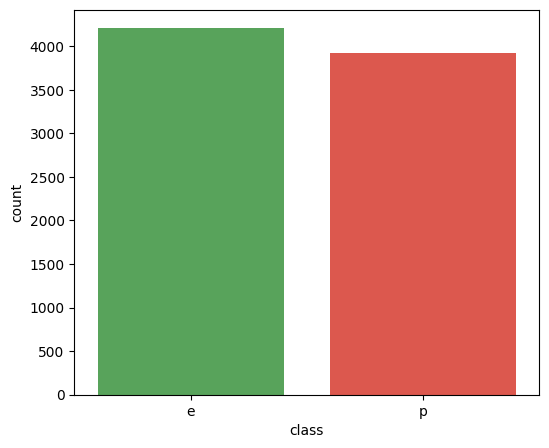

In [6]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(2))

plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=df, x='class', hue='class',
    order=['e', 'p'],
    palette={'e': '#4CAF50', 'p': '#F44336'},
    legend=False
)


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [7]:
X = df.drop(columns="class")
y = df["class"].map({"e": 0, "p": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (6499, 22)
Test : (1625, 22)


In [8]:
# Ubah penanda "?" menjadi missing value
X_train["stalk-root"] = X_train["stalk-root"].replace("?", np.nan)
X_test["stalk-root"] = X_test["stalk-root"].replace("?", np.nan)

# Catat status missing sebelum diisi
X_train["stalk_root_missing"] = (
    X_train["stalk-root"].isna().astype(int)
)

X_test["stalk_root_missing"] = (
    X_test["stalk-root"].isna().astype(int)
)

# Hitung modus HANYA dari train
modus_stalk_root = X_train["stalk-root"].mode()[0]

# Gunakan modus train untuk kedua bagian data
X_train["stalk-root"] = X_train["stalk-root"].fillna(modus_stalk_root)
X_test["stalk-root"] = X_test["stalk-root"].fillna(modus_stalk_root)

print("Modus dari train:", modus_stalk_root)
print("Missing awal train:", X_train["stalk_root_missing"].sum())
print("Missing awal test :", X_test["stalk_root_missing"].sum())

Modus dari train: b
Missing awal train: 1968
Missing awal test : 512


In [9]:
kolom_konstan = X_train.columns[
    X_train.nunique(dropna=False) == 1
].tolist()

X_train = X_train.drop(columns=kolom_konstan)
X_test = X_test.drop(columns=kolom_konstan)

print("Kolom yang dihapus:", kolom_konstan)
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Kolom yang dihapus: ['veil-type']
Train: (6499, 22)
Test : (1625, 22)


In [10]:
encoder_ordinal = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.int64
)

# Fit hanya pada train
X_train_cat = encoder_ordinal.fit_transform(X_train) + 1
X_test_cat = encoder_ordinal.transform(X_test) + 1

# Jumlah kategori setiap fitur, termasuk slot kategori baru (kode 0)
jumlah_kategori = [
    len(kategori) + 1
    for kategori in encoder_ordinal.categories_
]

print("Train categorical:", X_train_cat.shape)
print("Test categorical :", X_test_cat.shape)

Train categorical: (6499, 22)
Test categorical : (1625, 22)


In [11]:
encoder_ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Fit hanya pada train
X_train_ohe = encoder_ohe.fit_transform(X_train)
X_test_ohe = encoder_ohe.transform(X_test)

print("Train one-hot:", X_train_ohe.shape)
print("Test one-hot :", X_test_ohe.shape)

Train one-hot: (6499, 117)
Test one-hot : (1625, 117)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [12]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

# Inisialisasi dan latih CategoricalNB
model_cat = CategoricalNB()
model_cat.fit(X_train_cat, y_train)

print("Model CategoricalNB berhasil dilatih.")
print(f"Classes: {model_cat.classes_}")
print(f"Jumlah fitur: {model_cat.n_features_in_}")

Model CategoricalNB berhasil dilatih.
Classes: [0 1]
Jumlah fitur: 22


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

# Prediksi CategoricalNB pada test set
y_pred_cat = model_cat.predict(X_test_cat)
y_proba_cat = model_cat.predict_proba(X_test_cat)[:, 1]  # probabilitas kelas 1 (p=poisonous)

print(y_pred_cat[:10])
print(y_proba_cat[:10])

[1 0 0 1 1 0 0 0 0 0]
[1.00000000e+00 3.53768101e-01 1.13445626e-06 1.00000000e+00
 1.00000000e+00 2.17089840e-07 1.60283380e-08 2.89992034e-07
 6.98396134e-06 1.45500746e-01]


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [14]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.

# Inisialisasi dan latih BernoulliNB
model_bern = BernoulliNB()
model_bern.fit(X_train_ohe, y_train)

print("Model BernoulliNB berhasil dilatih.")
print(f"Classes: {model_bern.classes_}")
print(f"Jumlah fitur: {model_bern.n_features_in_}")

Model BernoulliNB berhasil dilatih.
Classes: [0 1]
Jumlah fitur: 117


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

# Prediksi BernoulliNB pada test set
y_pred_bern = model_bern.predict(X_test_ohe)
y_proba_bern = model_bern.predict_proba(X_test_ohe)[:, 1]  # probabilitas kelas 1 (p=poisonous)

print(y_pred_bern[:10])
print(y_proba_bern[:10])

[1 0 0 1 1 0 0 0 0 0]
[1.00000000e+00 3.90918704e-01 3.53303905e-10 1.00000000e+00
 1.00000000e+00 3.87596129e-09 1.02501207e-10 1.26837994e-09
 1.96061529e-08 9.88971029e-03]


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [16]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

# Inisialisasi dan latih MultinomialNB
model_multi = MultinomialNB()
model_multi.fit(X_train_ohe, y_train)

print("Model MultinomialNB berhasil dilatih.")
print(f"Classes: {model_multi.classes_}")
print(f"Jumlah fitur: {model_multi.n_features_in_}")

Model MultinomialNB berhasil dilatih.
Classes: [0 1]
Jumlah fitur: 117


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

# Prediksi MultinomialNB pada test set
y_pred_multi = model_multi.predict(X_test_ohe)
y_proba_multi = model_multi.predict_proba(X_test_ohe)[:, 1]  # probabilitas kelas 1 (p=poisonous)

print(y_pred_multi[:10])
print(y_proba_multi[:10])

[1 0 0 1 1 0 0 0 0 0]
[1.00000000e+00 3.53878520e-01 1.13500428e-06 1.00000000e+00
 1.00000000e+00 2.17194710e-07 1.60360808e-08 2.90132120e-07
 6.98733506e-06 1.45560802e-01]


# 4. Evaluasi Model

           Model  Accuracy
0  CategoricalNB    0.9385
2  MultinomialNB    0.9385
1    BernoulliNB    0.9280


C:\Users\pranaja\AppData\Local\Temp\ipykernel_25652\3545947843.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_acc, x='Model', y='Accuracy', palette='Set2')


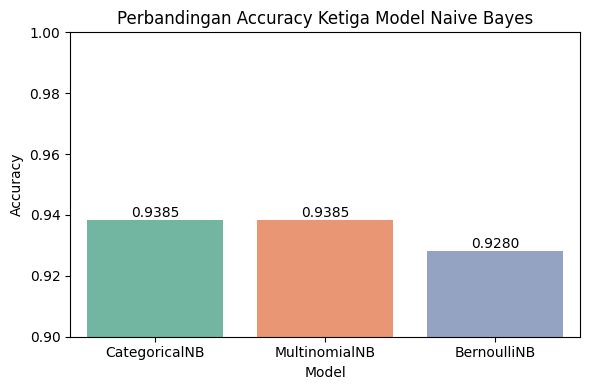

In [18]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
# Prediksi MultinomialNB pada test set
# Hitung accuracy ketiga model
acc_cat = accuracy_score(y_test, y_pred_cat)
acc_bern = accuracy_score(y_test, y_pred_bern)
acc_multi = accuracy_score(y_test, y_pred_multi)

# Sajikan dalam tabel
df_acc = pd.DataFrame({
    'Model': ['CategoricalNB', 'BernoulliNB', 'MultinomialNB'],
    'Accuracy': [acc_cat, acc_bern, acc_multi]
}).sort_values('Accuracy', ascending=False)

print(df_acc.round(4))

# Visualisasi perbandingan
plt.figure(figsize=(6,4))
sns.barplot(data=df_acc, x='Model', y='Accuracy', palette='Set2')
plt.ylim(0.9, 1.0)  # zoom karena accuracy biasanya tinggi di dataset ini
plt.title('Perbandingan Accuracy Ketiga Model Naive Bayes')
for i, v in enumerate(df_acc['Accuracy']):
    plt.text(i, v+0.001, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()

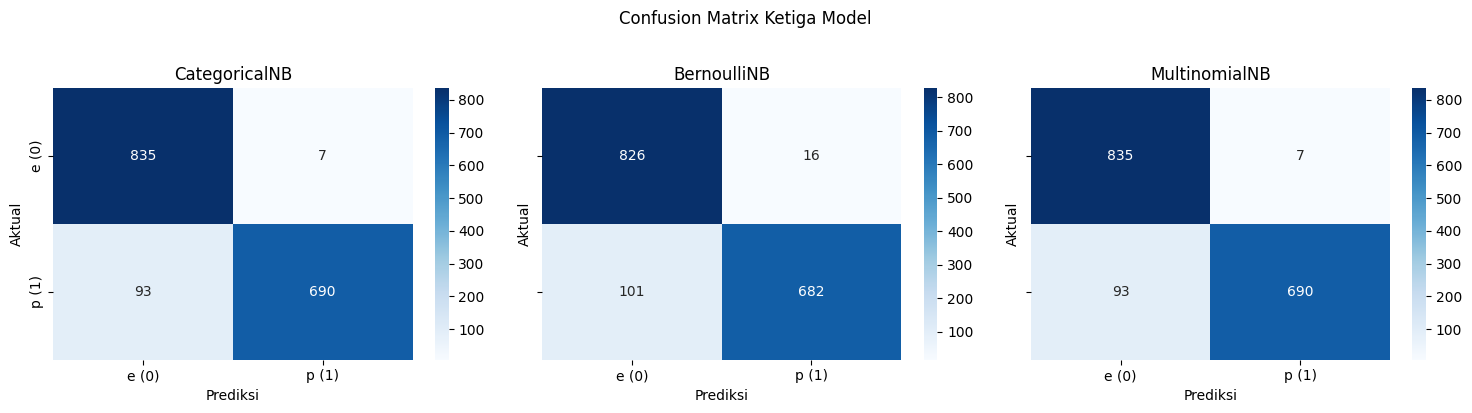

In [19]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

preds = [
    ("CategoricalNB", y_pred_cat),
    ("BernoulliNB", y_pred_bern),
    ("MultinomialNB", y_pred_multi),
]

for ax, (name, y_pred) in zip(axes, preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['e (0)', 'p (1)'],
                yticklabels=['e (0)', 'p (1)'])
    ax.set_title(name)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix Ketiga Model', y=1.02)
plt.tight_layout()
plt.show()

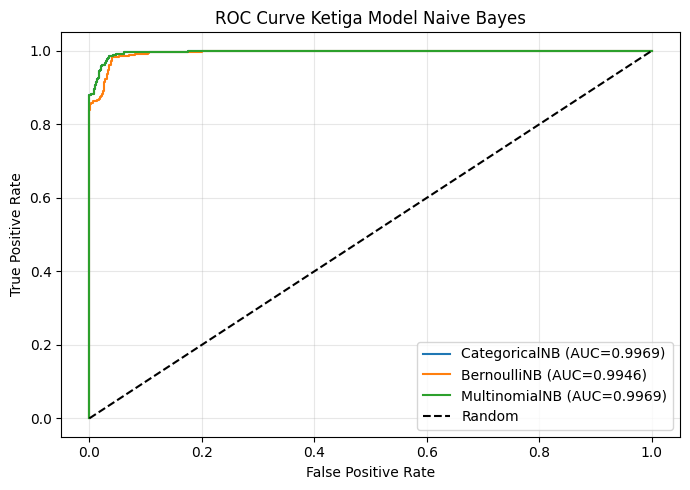

In [20]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

plt.figure(figsize=(7, 5))

for name, y_proba in [
    ("CategoricalNB", y_proba_cat),
    ("BernoulliNB", y_proba_bern),
    ("MultinomialNB", y_proba_multi),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Ketiga Model Naive Bayes')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Analisis

#### eksperimen pada dataset kali ini adalah membandingkan categorical Naive Bayes, Bernoulli Naive Bayes, dan Multinomial Naive Bayes. untuk fitur targetnya yaitu proporsi kelas edible dan poisonous mempunyai distribusi data yang balance dengan perbandingan sebesar 51,8% untuk edible dan 48,2% untuk poisonous. dataset tersebut memiliki fitur dalam bentuk kategorikal yang mana dapat kita lihat fitur yang dapat kita gunakan seperti bruises, odor, dan gil size dapat kita lihat persebarannya dapat digunakan untuk memisahkan poisonous dan edible. dataset ini memiliki beberapa missing value dan fitur kategori yang tidak dibutuhkan seperti pada stalk_root yang mana ada kategori ? yang mana saya interpretasikan sebagai missing value dan untuk fitur veil_type yang mana memiliki kategori yang konstan sehingga tidak dapat memberi insight. insight yang saya dapatkan di EDA memberikan saya keputusan untuk menangani beberapa hal seperti missing value yang dalam bentuk ? saya mengambil keputusan untuk saya imput dengan modus tapi saya buat fitur baru untuk mengatasi hal tersebut sebagai penanda missing enggaknya dan untuk fitur yang memiliki kategori konstan saya memilih untuk drop hal tersebut untuk menghindari noise. fitur-fitur kategorikalnya saya lakukan encoding terlebih dahulu sebelum modelling. categorical Naive Bayes menggunakan ordinalencoding untuk mengubah fitur kategorikal menjadi integer setelah itu menghitung peluang masing masing fitur dan untuk multinomial dan bernoulli itu menggunakan one hot encoding dengan memecah fitur menjadi fitur biner sesuai encoding pada classnya dan hasilnya categorical dan multinomial mendapatkan 0.9385 dan bernoulli 0.928

# 6. Kesimpulan dan Saran

#### berdasarkan eksperimen yang dibuat dapat kita lihat bahwa hasil dari categorical dan multinomial memiliki accuracy 0.9385 dan bernoulli sebesar 0.928 yang mana categorical memiliki hasil accuracy lebih baik. meskipun categorical dan multimodal memiliki accuracy yang sama, kedua model tersebut memiliki pendekatan yang berbeda dalam memprediksi data testnya. saran untuk eksperimen ke depannya adalah menggunakan Stratified K-Fold Cross-Validation dan bandingkan strategi dalam penanganan missing value